## Memory

#### Reference URL

https://microsoft.github.io/autogen/stable//user-guide/agentchat-user-guide/memory.html

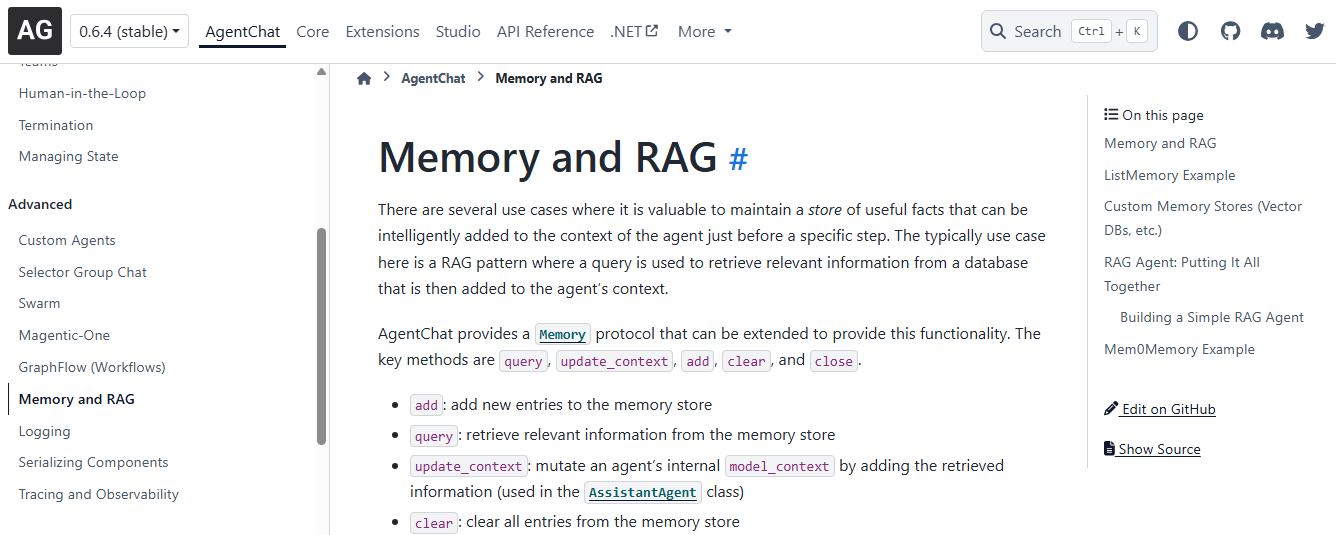

In [1]:
from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_agentchat.ui import Console
from autogen_core.memory import ListMemory, MemoryContent, MemoryMimeType

In [2]:
import os
from dotenv import load_dotenv

# Configure API Key
load_dotenv()

api_key= os.getenv("OPENAI_API_KEY")

### List Memory
#### Reference URL
https://microsoft.github.io/autogen/stable//reference/python/autogen_core.memory.html#autogen_core.memory.ListMemory

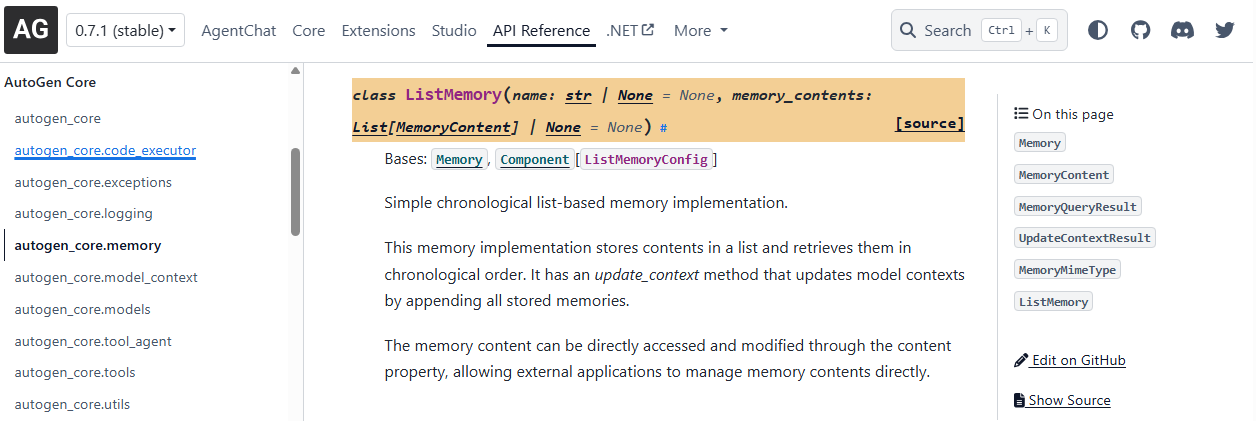

In [5]:
userMemory= ListMemory()

### Memory Content
#### Reference URL

https://microsoft.github.io/autogen/stable//reference/python/autogen_core.memory.html#autogen_core.memory.MemoryContent

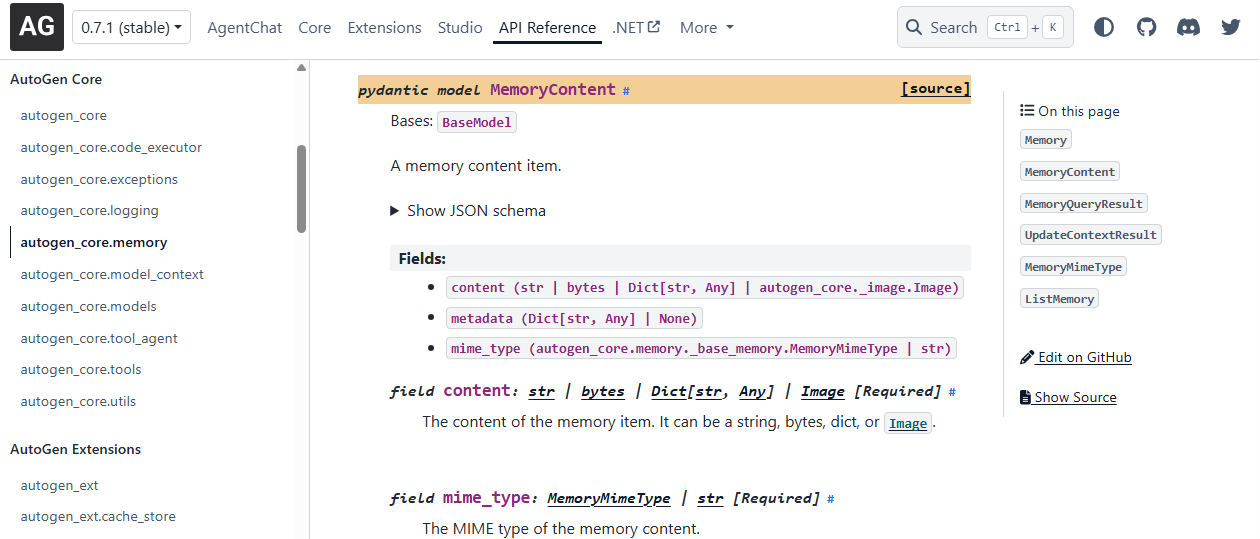

In [22]:
await userMemory.add(MemoryContent(
        content='The weather unit should be degree celsius (metric)',
        mime_type=MemoryMimeType.TEXT,
    )
)

#### Weather tools

In [19]:
async def get_weather(city: str, units: str = "imperial") -> str:
    if units == "imperial":
        return f"The weather in {city} is 73 °F and Sunny."
    elif units == "metric":
        return f"The weather in {city} is 23 °C and Sunny."
    else:
        return f"Sorry, I don't know the weather in {city}."

#### Weather Assistant Agent

In [20]:
assistant_agent= AssistantAgent(
    name="weather_assistant",
    model_client=OpenAIChatCompletionClient(model='gpt-4o', api_key=api_key),
    tools=[get_weather],
    memory=[userMemory]
)

In [16]:
stream= assistant_agent.run_stream(task='What is the weather in Delhi ?')

await Console(stream)

---------- TextMessage (user) ----------
What is the weather in Delhi ?
---------- MemoryQueryEvent (weather_assistant) ----------
[MemoryContent(content='The weather unit should be degree celsius (metric)', mime_type=<MemoryMimeType.TEXT: 'text/plain'>, metadata=None), MemoryContent(content='The weather unit should be degree celsius (metric)', mime_type=<MemoryMimeType.TEXT: 'text/plain'>, metadata=None)]
---------- ToolCallRequestEvent (weather_assistant) ----------
[FunctionCall(id='call_rzZn1HZ0NqZ3FRiRHvY9Hrgc', arguments='{"city":"Delhi","units":"metric"}', name='get_weather')]
---------- ToolCallExecutionEvent (weather_assistant) ----------
[FunctionExecutionResult(content='The weather in Delhi is 23 °C and Sunny.', name='get_weather', call_id='call_rzZn1HZ0NqZ3FRiRHvY9Hrgc', is_error=False)]
---------- ToolCallSummaryMessage (weather_assistant) ----------
The weather in Delhi is 23 °C and Sunny.


TaskResult(messages=[TextMessage(id='6cda2ddb-b73d-4556-b02b-082e7b424a64', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 29, 12, 41, 17, 692155, tzinfo=datetime.timezone.utc), content='What is the weather in Delhi ?', type='TextMessage'), MemoryQueryEvent(id='fff1a494-791e-4f1a-a818-9a88203c48e9', source='weather_assistant', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 29, 12, 41, 17, 696190, tzinfo=datetime.timezone.utc), content=[MemoryContent(content='The weather unit should be degree celsius (metric)', mime_type=<MemoryMimeType.TEXT: 'text/plain'>, metadata=None), MemoryContent(content='The weather unit should be degree celsius (metric)', mime_type=<MemoryMimeType.TEXT: 'text/plain'>, metadata=None)], type='MemoryQueryEvent'), ToolCallRequestEvent(id='bddcc2cd-f47b-42a0-bded-533f3011a8f1', source='weather_assistant', models_usage=RequestUsage(prompt_tokens=220, completion_tokens=18), metadata={}, created_at=datetime.d

#### Structured Output

In [ ]:
TaskResult(messages=[
    TextMessage(id='6cda2ddb-b73d-4556-b02b-082e7b424a64', 
                source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 29, 12, 41, 17, 692155, tzinfo=datetime.timezone.utc), 
                content='What is the weather in Delhi ?', type='TextMessage'), 
                
    MemoryQueryEvent(id='fff1a494-791e-4f1a-a818-9a88203c48e9', 
                     source='weather_assistant', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 29, 12, 41, 17, 696190, tzinfo=datetime.timezone.utc), 
                     content=[MemoryContent(content='The weather unit should be degree celsius (metric)', mime_type=<MemoryMimeType.TEXT: 'text/plain'>, metadata=None), 
                              MemoryContent(content='The weather unit should be degree celsius (metric)', mime_type=<MemoryMimeType.TEXT: 'text/plain'>, metadata=None)], type='MemoryQueryEvent'), 
                              
                    ToolCallRequestEvent(id='bddcc2cd-f47b-42a0-bded-533f3011a8f1', 
                                         source='weather_assistant', models_usage=RequestUsage(prompt_tokens=220, completion_tokens=18), metadata={}, created_at=datetime.datetime(2025, 7, 29, 12, 41, 19, 395435, tzinfo=datetime.timezone.utc), 
                                         content=[FunctionCall(id='call_rzZn1HZ0NqZ3FRiRHvY9Hrgc', arguments='{"city":"Delhi","units":"metric"}', name='get_weather')], type='ToolCallRequestEvent'), 
                                         
                    ToolCallExecutionEvent(id='5d2599fa-58a9-4e12-a5a1-b165b65718ee', 
                                           source='weather_assistant', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 29, 12, 41, 19, 403403, tzinfo=datetime.timezone.utc), 
                                           content=[FunctionExecutionResult(content='The weather in Delhi is 23 °C and Sunny.', name='get_weather', call_id='call_rzZn1HZ0NqZ3FRiRHvY9Hrgc', is_error=False)], type='ToolCallExecutionEvent'), 
                                           
                    ToolCallSummaryMessage(id='1485e7b5-7969-489c-aef1-8cd69a4627fc', 
                                           source='weather_assistant', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 29, 12, 41, 19, 406986, tzinfo=datetime.timezone.utc), 
                                           content='The weather in Delhi is 23 °C and Sunny.', type='ToolCallSummaryMessage', tool_calls=[FunctionCall(id='call_rzZn1HZ0NqZ3FRiRHvY9Hrgc', arguments='{"city":"Delhi","units":"metric"}', name='get_weather')], results=[FunctionExecutionResult(content='The weather in Delhi is 23 °C and Sunny.', name='get_weather', call_id='call_rzZn1HZ0NqZ3FRiRHvY9Hrgc', is_error=False)])], 
           
    stop_reason=None)

In [ ]:
stream= assistant_agent.run_stream(task='What is the weather of Bihar?')

await Console(stream)

---------- TextMessage (user) ----------
What is the weather of Bihar?
---------- MemoryQueryEvent (weather_assistant) ----------
[MemoryContent(content='The weather unit should be degree celsius (metric)', mime_type=<MemoryMimeType.TEXT: 'text/plain'>, metadata=None), MemoryContent(content='The weather unit should be degree celsius (metric)', mime_type=<MemoryMimeType.TEXT: 'text/plain'>, metadata=None)]
---------- ToolCallRequestEvent (weather_assistant) ----------
[FunctionCall(id='call_UKvETgto60lyxqeF4XN5kyzt', arguments='{"city":"Bihar","units":"metric"}', name='get_weather')]
---------- ToolCallExecutionEvent (weather_assistant) ----------
[FunctionExecutionResult(content='The weather in Bihar is 23 °C and Sunny.', name='get_weather', call_id='call_UKvETgto60lyxqeF4XN5kyzt', is_error=False)]
---------- ToolCallSummaryMessage (weather_assistant) ----------
The weather in Bihar is 23 °C and Sunny.


TaskResult(messages=[TextMessage(id='da45e73d-8755-40bf-91a6-62dcd707c317', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 29, 12, 40, 2, 40850, tzinfo=datetime.timezone.utc), content='What is the weather of Bihar?', type='TextMessage'), MemoryQueryEvent(id='38920112-08e4-4498-bf64-062acc47d635', source='weather_assistant', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 29, 12, 40, 2, 56374, tzinfo=datetime.timezone.utc), content=[MemoryContent(content='The weather unit should be degree celsius (metric)', mime_type=<MemoryMimeType.TEXT: 'text/plain'>, metadata=None), MemoryContent(content='The weather unit should be degree celsius (metric)', mime_type=<MemoryMimeType.TEXT: 'text/plain'>, metadata=None)], type='MemoryQueryEvent'), ToolCallRequestEvent(id='0613d9bb-ec99-4dfc-a0a3-22da418f9f72', source='weather_assistant', models_usage=RequestUsage(prompt_tokens=130, completion_tokens=19), metadata={}, created_at=datetime.dateti

#### Structured Output

In [ ]:
TaskResult(
    messages=[
        TextMessage(id='da45e73d-8755-40bf-91a6-62dcd707c317', 
                    source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 29, 12, 40, 2, 40850, tzinfo=datetime.timezone.utc), 
                    content='What is the weather of Bihar?', type='TextMessage'), 
                    
        MemoryQueryEvent(id='38920112-08e4-4498-bf64-062acc47d635', 
                         source='weather_assistant', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 29, 12, 40, 2, 56374, tzinfo=datetime.timezone.utc), 
                         content=[MemoryContent(content='The weather unit should be degree celsius (metric)', mime_type=<MemoryMimeType.TEXT: 'text/plain'>, metadata=None), 
                                  MemoryContent(content='The weather unit should be degree celsius (metric)', mime_type=<MemoryMimeType.TEXT: 'text/plain'>, metadata=None)], type='MemoryQueryEvent'), 
                                  
        ToolCallRequestEvent(id='0613d9bb-ec99-4dfc-a0a3-22da418f9f72', 
                             source='weather_assistant', models_usage=RequestUsage(prompt_tokens=130, completion_tokens=19), metadata={}, created_at=datetime.datetime(2025, 7, 29, 12, 40, 5, 143385, tzinfo=datetime.timezone.utc), 
                             content=[FunctionCall(id='call_UKvETgto60lyxqeF4XN5kyzt', arguments='{"city":"Bihar","units":"metric"}', name='get_weather')], type='ToolCallRequestEvent'), 
                             
        ToolCallExecutionEvent(id='fb476df4-b857-4d15-9f8f-ce110de27503', 
                               source='weather_assistant', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 29, 12, 40, 5, 148938, tzinfo=datetime.timezone.utc), 
                               content=[FunctionExecutionResult(content='The weather in Bihar is 23 °C and Sunny.', name='get_weather', call_id='call_UKvETgto60lyxqeF4XN5kyzt', is_error=False)], type='ToolCallExecutionEvent'), 
                               
        ToolCallSummaryMessage(id='62301b41-ca81-48d1-931b-9adc990078ba', 
                               source='weather_assistant', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 29, 12, 40, 5, 152757, tzinfo=datetime.timezone.utc), 
                               content='The weather in Bihar is 23 °C and Sunny.', type='ToolCallSummaryMessage', tool_calls=[FunctionCall(id='call_UKvETgto60lyxqeF4XN5kyzt', arguments='{"city":"Bihar","units":"metric"}', name='get_weather')], 
                               results=[FunctionExecutionResult(content='The weather in Bihar is 23 °C and Sunny.', name='get_weather', call_id='call_UKvETgto60lyxqeF4XN5kyzt', is_error=False)])], 
           
           
    stop_reason=None)